In [5]:
"""
This script is designed to help visualize and compare the power outputs of critical slopes.
I used a fit function with 2 exponential decay terms to fit the IV data I found.
this script is a litte finecky about the initial parameters before it fits, because there are so many.
the solution is to pick 2 points, like VOC and ISC and find a reasonable fit is desmos before using those values to fit the curve.

I needed to weight the last 150 samples in order to get a more accurate fit around the peak and cliff.
"""

'\nThis script is designed to help visualize and compare the power outputs of critical slopes.\nI used a fit function with 2 exponential decay terms to fit the IV data I found.\nthis script is a litte finecky about the initial parameters before it fits, because there are so many.\nthe solution is to pick 2 points, like VOC and ISC and find a reasonable fit is desmos before using those values to fit the curve.\n\nI needed to weight the last 150 samples in order to get a more accurate fit around the peak and cliff.\n'

In [8]:
# IMPORTS
#determine how different critical slopes effect the popwer output of the system.
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

# %matplotlib inline

In [9]:
# DEFINITIONS

def iv1(I, Voc, lin, a, b, c, d, e, f):
    #print(I, Voc, lin, a, b, c)
    return Voc - lin*I - a*(np.exp(np.clip((b*I-c), -700, 700))) - d*(np.exp(np.clip((e*I-f), -700, 700)))

def iv2(I, Voc, lin, a, b, c):
    #print(I, Voc, lin, a, b, c)
    return Voc - lin*I - a*(np.exp(np.clip((b*I-c), -700, 700)))

def slope(slope, val, offset):
    return slope*val + offset

def const(offset, val):
    return offset + 0*val

def get_first_value(x):
    # If it's a numpy array or list-like, index into it
    if isinstance(x, (list, tuple, np.ndarray)):
        if np.ndim(x) > 1 and len(x) > 0:
            return x[0][0]
        elif len(x) > 0:
            return x[0]
        else:
            return 0
    return x

#print
def process(csv, params):
    data = np.transpose(csv.to_numpy()).astype(np.float128)

    weights = [1] * len(data[0])

    #make the last 50 samples count more, because we care about the high current data more than the low current data
    for idx in range(50):
        weights[len(weights) - (idx+1)] = 10
        
    sigma = 1 / np.sqrt(weights)
    
    popt, pcov = curve_fit(iv1, data[0], data[1], sigma=sigma, maxfev=100000, absolute_sigma=True, p0=params)

    I_fit = np.linspace(min(data[0]), max(data[0]), 1000)
    V_fit = iv1(I_fit, *popt)
    P_fit = V_fit*I_fit*0.000001

    return I_fit, V_fit, P_fit, data


def find_intercects(slope, current, power):
    return np.argwhere(abs(const(slope, current)-np.gradient(power,current)) < 0.000015)

def graph_data_vs_fit(data, current, voltage, title):
    plt.plot(data[0], data[1], 'o', label='Data')
    plt.plot(current, voltage, '-', label='Fit')
    plt.xlabel('Current (uA)')
    plt.ylabel('Voltage (mV)')
    plt.title(title + " IV data and fit line")
    # plt.ylim(0,)
    plt.legend()
    plt.grid(True)
    plt.show()

def find_diffs(slopes, intercects, current, power):
    diffs = [0] * len(slopes)
    for idx in range(len(slopes)):    
        diffs[idx] = power[intercects[idx]] - slope(slopes[idx], current[intercects[idx]], 0)
    return diffs

def graph_intercects(slopes, intercects, current, power, data, diffs, title):
    #plot data
    #plt.plot(data[0], data[2], 'o', label="Data")
    #plot fit line
    plt.plot(current, power, '-', label="Fit")

    for idx in range(len(slopes)):
        plt.plot(current, slope(slopes[idx], current, diffs[idx]), label='slope='+str(slopes[idx])+'mW/uA')
        plt.plot(current[intercects[idx]], slope(slopes[idx], current[intercects[idx]], diffs[idx]), 'ro',)
    

    #plt.xlim(170500,200000)
    plt.xlim(280000,360000)
    #plt.ylim(880,1025)
    plt.ylim(1450,1800)
    plt.legend()
    #plt.plot(I_fit, data[2])
    plt.title(title + " Critical Points of various slopes")
    plt.xlabel("Current (uA)")
    plt.ylabel("Power (mW)")
    plt.show()
    

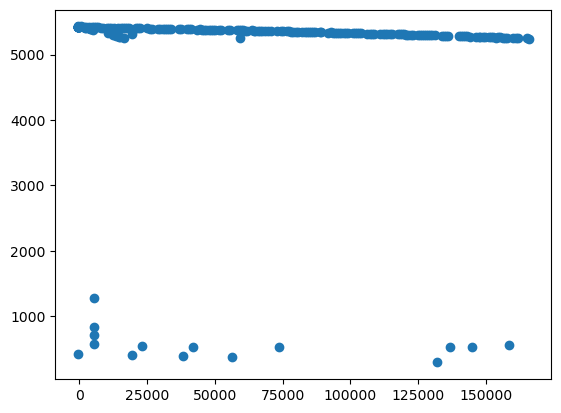

In [28]:
# WORKSPACE

def idk(csv, params, title):
    I_fit, V_fit, P_fit, data = process(csv, params)
    graph_data_vs_fit(data, I_fit, V_fit, title)
    
    # slopes = [0.0041, 0.00425, 0.0045]
    slopes = [0.00425]
    intercects = [0] * len(slopes)
    
    for idx, lslope in enumerate(slopes):
        intercects[idx] = get_first_value(find_intercects(lslope, I_fit, P_fit))
    
    diffs = find_diffs(slopes, intercects, I_fit, P_fit)
    
    #print diffs
    for diff in diffs:
        print("power: ", diff)
    
    graph_intercects(slopes, intercects, I_fit, P_fit, data, diffs, title)

# mycsv1 = pd.read_csv('data/filtered/0.1.csv', sep=' ')
# mycsv2 = pd.read_csv('data/filtered/0.2.csv', sep=' ')
# mycsv3 = pd.read_csv('data/filtered/0.3.csv', sep=' ')
# mycsv4 = pd.read_csv('data/filtered/0.4.csv', sep=' ')
# mycsv5 = pd.read_csv('data/filtered/0.5.csv', sep=' ')
# mycsv6 = pd.read_csv('data/filtered/0.6.csv', sep=' ')
# mycsv7 = pd.read_csv('data/filtered/0.7.csv', sep=' ')
# mycsv8 = pd.read_csv('data/filtered/0.8.csv', sep=' ')
# mycsv9 = pd.read_csv('data/filtered/0.9.csv', sep=' ')
# mycsv10 = pd.read_csv('data/filtered/1.0.csv', sep=' ')

csvarr = [0] * 9 #CHANGE BACK TO TEN OH  MY GOD

csvfiles = [
    "10p",
    "20p",
    "30p",
    "40p",
    "50p",
    "60p",
    "70p",
    # "80p",
    "90p",
    "100p"
]

for idx in range(len(csvarr)):
    csvarr[idx] = pd.read_csv('mcxn_GaAs sweeps/processed/'+csvfiles[idx]+".csv", sep=',')
    

# p40 = csvarr[3]
# plt.scatter(p40['current_uA'].tolist(), p40['voltage_mV'].tolist())
# plt.xlim(0,200000)
# plt.ylim(-1,1)
# print(p40['current_uA'].tolist(), p40['voltage_mV'].tolist())

# idk(csvarr[5], [5450, 0.00001, 1, 0.00005, 3.5, 1, 0.00005, 3.5], "50% intensity")


# idk(mycsv1, [5450, 0.00001, 1, 0.00005, 3.5, 1, 0.00005, 3.5], "10% intensity")
# idk(mycsv2, [5400, 0.00005, 1, 0.0000385, 3.5, 1.9, 0.00001, 3.5], "20% intensity")
# idk(mycsv3, [5450, 0.00001, 1, 0.00005, 3.5, 1, 0.00005, 3.5], "30% intensity")
# idk(mycsv4, [5400, 0.00005, 1, 0.0000385, 3.5, 1.9, 0.00001, 3.5], "40% intensity")
# idk(mycsv5, [5460, 0.00068, 1, 0.0000298, 3.5, 0, 0, 0], "50% intensity")
# idk(mycsv6, [5450, 0.00001, 1, 0.00005, 3.5, 1, 0.00005, 3.5], "")
# idk(mycsv7, [5500, 0.00001, 1, 0.0000385, 3.5, 1.9, 0.00001, 3.5], "70% intensity")
# idk(mycsv8, [5450, 0.00001, 1, 0.00005, 3.5, 1, 0.00005, 3.5], "80% intensity")
# idk(mycsv9, [5460, 0.00009, 5, 0.000024, 3.5, 2.8, 0.000025, 3.5], "90% intensity")
# idk(mycsv10, [5450, 0.00001, 1, 0.00005, 3.5, 1, 0.00005, 3.5], "100% intensity")

# idk(mycsv1, [5460, 0.00068, 1, 0.0000298, 3.5], "0.1 intensity")
# idk(mycsv2, [5360, 0.00137, 1, 0.000066, 3.5], "0.2 intensity")
# idk(mycsv3, [5360, 0.0006, 1, 0.000048, 3.5], "0.3 intensity")
# idk(mycsv4, [5460, 0.00068, 1, 0.0000298, 3.5], "0.4 intensity")
# idk(mycsv5, [5460, 0.00068, 1, 0.0000298, 3.5], "0.5 intensity")
# idk(mycsv6, [5460, 0.00068, 1, 0.0000298, 3.5], "0.6 intensity")
# idk(mycsv7, [5460, 0.00068, 1, 0.0000298, 3.5], "0.7 intensity")
# idk(mycsv8, [5460, 0.00068, 1, 0.0000298, 3.5], "0.8 intensity")
# idk(mycsv9, [5460, 0.00068, 1, 0.0000298, 3.5], "0.9 intensity")
# idk(mycsv10, [5460, 0.00068, 1, 0.0000298, 3.5], "1.0 intensity")




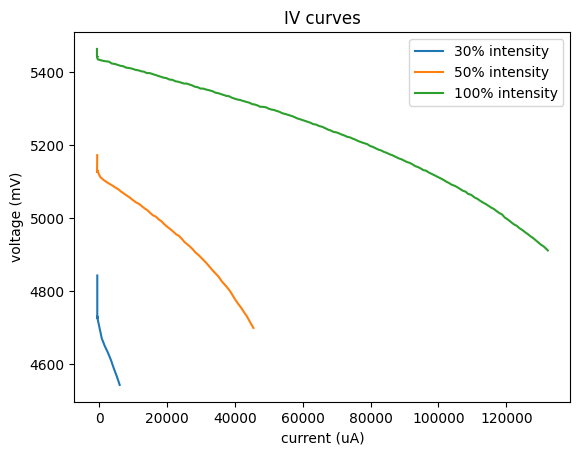

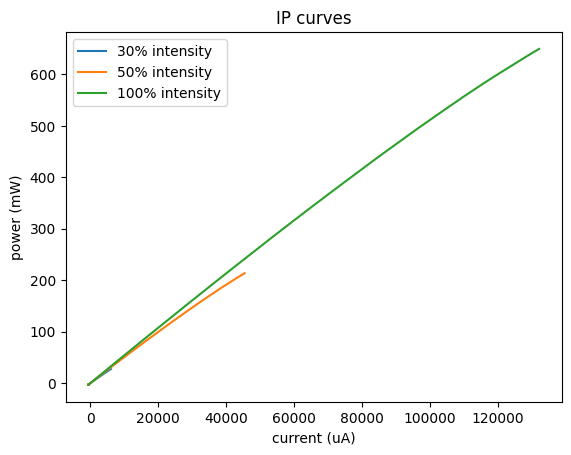

In [7]:
#plot multiple CSVs


data1 = np.transpose(mycsv1.to_numpy()).astype(np.float128)
data5 = np.transpose(mycsv5.to_numpy()).astype(np.float128)
data9 = np.transpose(mycsv9.to_numpy()).astype(np.float128)

# fig, (ax1, ax2) = plt.subplots(1, 2)
fig, ax = plt.subplots()
#0.1
ax.plot(data1[0], data1[1], label="10% intensity")
ax.plot(data1[0][-1], data1[1][-1], 'r*', label="browned out")

#0.5
ax.plot(data5[0], data5[1], label="50% intensity")
ax.plot(data5[0][-1], data5[1][-1], 'r*')

#0.9
ax.plot(data9[0], data9[1], label="90% intensity")
ax.plot(data9[0][-1], data9[1][-1], 'r*')

ax.legend()

plt.xlabel("current (uA)")
plt.ylabel("voltage (mV)")
plt.title("IV curves")

plt.show()

plt.plot(data1[0], data1[2], label="10% intensity")
plt.plot(data1[0][-1], data1[2][-1], 'r*', label="browned out")
plt.plot(data5[0], data5[2], label="50% intensity")
plt.plot(data5[0][-1], data5[2][-1], 'r*')
plt.plot(data9[0], data9[2], label="90% intensity")
plt.plot(data9[0][-1], data9[2][-1], 'r*')
plt.legend()
plt.xlabel("current (uA)")
plt.ylabel("power (mW)")
plt.title("IP curves")

plt.show()




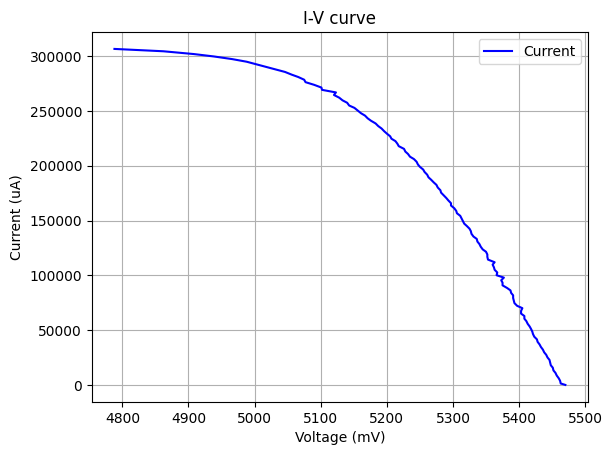

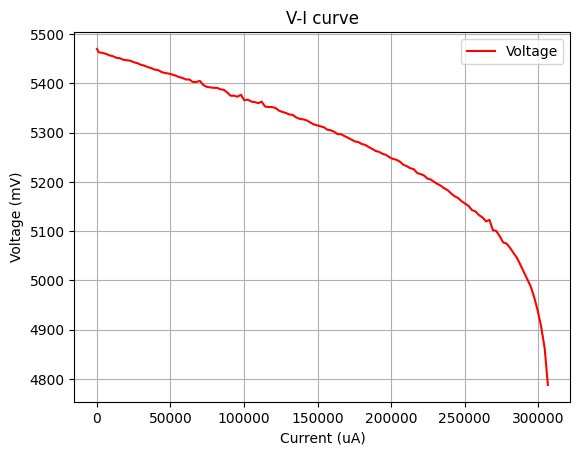

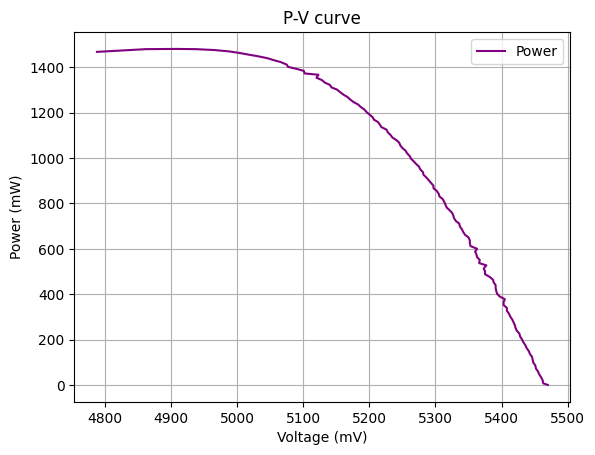

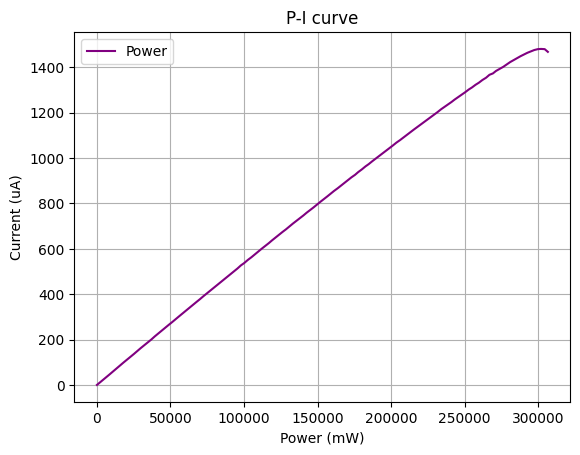

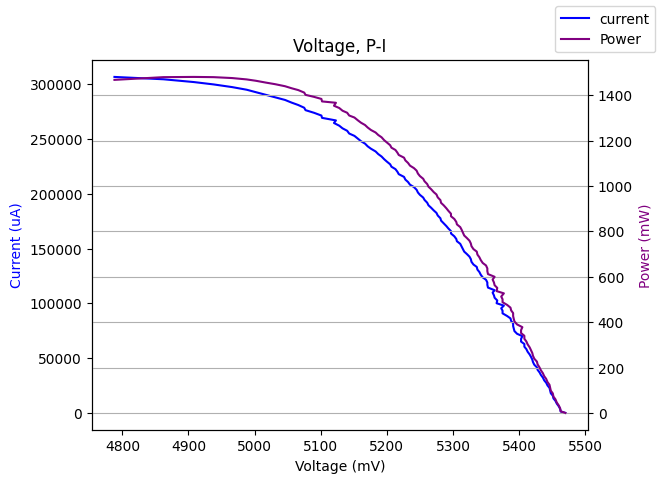

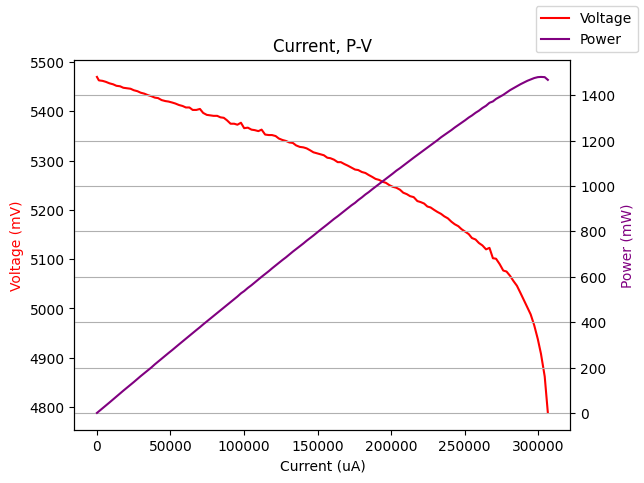

In [14]:


#voltage current
plt.plot(data5[1], data5[0], label="Current", c="blue")
plt.xlabel("Voltage (mV)")
plt.ylabel("Current (uA)")
plt.title("I-V curve")
plt.legend()
plt.grid()
plt.show()

# current voltage
plt.plot(data5[0], data5[1], label="Voltage", c="red")
plt.xlabel("Current (uA)")
plt.ylabel("Voltage (mV)")
plt.title("V-I curve")
plt.legend()
plt.grid()
plt.show()

#power voltage
plt.plot(data5[1], data5[2], label="Power", c="purple")
plt.xlabel("Voltage (mV)")
plt.ylabel("Power (mW)")
plt.title("P-V curve")
plt.legend()
plt.grid()
plt.show()

#power current
plt.plot(data5[0], data5[2], label="Power", c="purple")
plt.xlabel("Power (mW)")
plt.ylabel("Current (uA)")
plt.title("P-I curve")
plt.legend()
plt.grid()
plt.show()

# #power current
# plt.plot(data5[0], data5[2], label="Power", c="purple")
# plt.xlabel("Power (mW)")
# plt.ylabel("Current (uA)")
# plt.title("P-I curve")
# plt.legend()
# plt.xlim(0, 500000)
# plt.show()

fig, ax1 = plt.subplots()
plt.xlabel("Voltage (mV)")
ax1.set_ylabel("Current (uA)", color='b')
ax2 = plt.twinx()
ax2.set_ylabel("Power (mW)", color='purple')
plt.title("Voltage, P-I")
ax1.plot(data5[1], data5[0], label="current", c="blue")
ax2.plot(data5[1], data5[2], label="Power", c="purple")
# ax1.set_ylim(0,350000)
fig.legend()
plt.grid()
plt.show()

fig, ax1 = plt.subplots()
plt.xlabel("Current (uA)")
ax1.set_ylabel("Voltage (mV)", color='r')
ax2 = plt.twinx()
ax2.set_ylabel("Power (mW)", color='purple')
plt.title("Current, P-V")
ax1.plot(data5[0], data5[1], label="Voltage", c="red")
ax2.plot(data5[0], data5[2], label="Power", c="purple")
fig.legend()
plt.grid()
plt.show()
# # current voltage
# plt.plot(data5[0], data5[1], label="Voltage", c="red")
# plt.xlabel("Current (uA)")
# plt.ylabel("Voltage (mV)")
# plt.title("Voltage, PI")
# plt.legend()
# plt.grid()
# plt.show()

# #power voltage
# plt.plot(data5[1], data5[2], label="Power", c="purple")
# plt.xlabel("Voltage (mV)")
# plt.ylabel("Power (mW)")
# plt.title("P-V curve")
# plt.legend()
# plt.grid()
# plt.show()
